# Load Data

In [16]:
from prepare_boroughs import prepare_borough_data
import pandas as pd
import numpy as np

In [21]:
borough_df = prepare_borough_data()

DataFrame Cleaned Successfully...
DataFrame Information:
>>> Columns:
Index(['LA_2023', 'LondInOut', 'MEMS7_ALL', 'LOG_MEMS7_ALL', 'active', 'year',
       'LA_Name'],
      dtype='object')
>>> Shape (117679, 7)


In [23]:
borough_df.columns

Index(['LA_2023', 'LA_Name', 'year', 'MEMS7_ALL'], dtype='object')

In [24]:
borough_df.dtypes

LA_2023      float64
LA_Name       object
year          object
MEMS7_ALL    float64
dtype: object

In [25]:
train_df = borough_df[borough_df['year'].isin(['2016/17','2017/18','2018/19','2019/20','2020/21'])]
val_df = borough_df[borough_df['year'] == '2021/22']
test_df = borough_df[borough_df['year'] == '2022/23']

year_order = {'2016/17': 0, '2017/18': 1, '2018/19': 2, '2019/20': 3, '2020/21': 4, '2021/22': 5, '2022/23': 6}

train_df = train_df.copy()
train_df['time'] = train_df['year'].map(year_order)

test_df = test_df.copy()
test_df['time'] = test_df['year'].map(year_order)

val_df = val_df.copy()
val_df['time'] = val_df['year'].map(year_order)

t_train = train_df['time'].values
y_train = train_df['MEMS7_ALL'].values

# Bayesian Linear Regression

In [54]:
train_agg = train_df.groupby(['LA_Name', 'time'])['MEMS7_ALL'].mean().reset_index()
merton = train_agg[train_agg['LA_Name'] == 'Merton']
t_b = merton['time'].values
y_b = merton['MEMS7_ALL'].values

print(t_b)
print(y_b)


[0 1 2 3 4]
[747.57358871 671.63232323 740.49853229 644.58028846 702.41496945]


In [73]:
import numpy as np
import pymc as pm

covid = np.where(t_b == 3, 1, 0)

with pm.Model() as covid_model:
    alpha = pm.Normal('alpha', mu=700, sigma=50)
    beta = pm.Normal('beta', mu=0, sigma=5)
    gamma = pm.Normal('gamma', mu=-50, sigma=30)
    sigma = pm.HalfNormal('sigma', sigma=50)

    mu = alpha + beta * t_b + gamma * covid
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y_b)

    trace = pm.sample(2000, tune=1000, return_inferencedata=True)

import arviz as az
print(az.summary(trace, var_names=['alpha', 'beta', 'gamma']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


          mean      sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha  712.639  19.444  674.234  747.934      0.290    0.269    4637.0   
beta    -0.901   4.584   -9.923    7.419      0.061    0.050    5602.0   
gamma  -56.282  24.620 -102.270   -9.666      0.330    0.305    5594.0   

       ess_tail  r_hat  
alpha    4715.0    1.0  
beta     5241.0    1.0  
gamma    5022.0    1.0  


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'gamma'}>,
        <Axes: title={'center': 'gamma'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

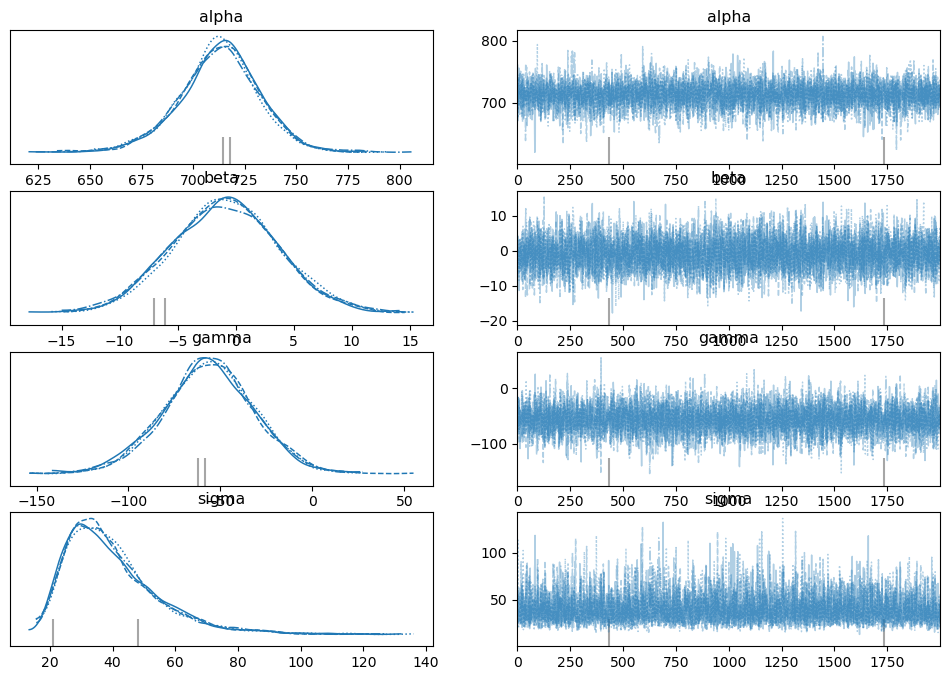

In [74]:
import arviz as az
az.plot_trace(trace)

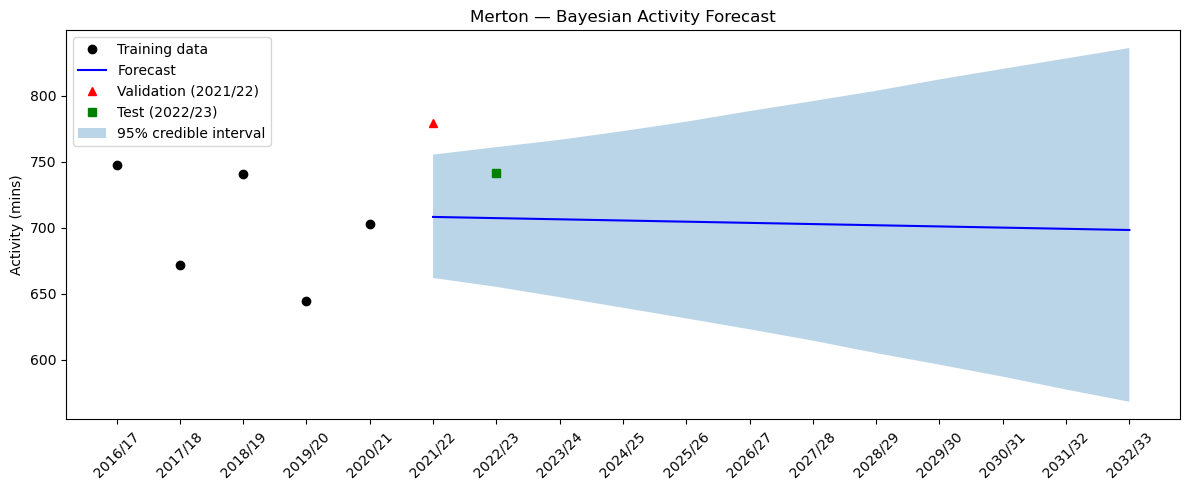

In [75]:
import matplotlib.pyplot as plt

alpha_samples = trace.posterior['alpha'].values.flatten()
beta_samples = trace.posterior['beta'].values.flatten()

future_t = np.arange(5, 17)

preds = alpha_samples[:, None] + beta_samples[:, None] * future_t

mean_pred = preds.mean(axis=0)
lower = np.percentile(preds, 2.5, axis=0)
upper = np.percentile(preds, 97.5, axis=0)

future_years = ['2021/22','2022/23','2023/24','2024/25','2025/26',
                '2026/27','2027/28','2028/29','2029/30','2030/31',
                '2031/32','2032/33']

plt.figure(figsize=(12, 5))
plt.plot(range(5), y_b, 'ko', label='Training data')
plt.plot(range(5, 17), mean_pred, 'b-', label='Forecast')

val_merton = val_df[val_df['LA_Name'] == 'Merton']['MEMS7_ALL'].mean()
test_merton = test_df[test_df['LA_Name'] == 'Merton']['MEMS7_ALL'].mean()

plt.plot([5], [val_merton], 'r^', label='Validation (2021/22)', zorder=5)
plt.plot([6], [test_merton], 'gs', label='Test (2022/23)', zorder=5)

plt.fill_between(range(5, 17), lower, upper, alpha=0.3, label='95% credible interval')
plt.xticks(range(17), ['2016/17','2017/18','2018/19','2019/20','2020/21'] + future_years, rotation=45)
plt.ylabel('Activity (mins)')
plt.title('Merton — Bayesian Activity Forecast')
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
val_pred = alpha_samples.mean() + beta_samples.mean() * 5
mape_val = abs(val_pred - val_merton) / val_merton * 100

test_pred = alpha_samples.mean() + beta_samples.mean() * 6
mape_test = abs(test_pred - test_merton) / test_merton * 100

print(f'Validation MAPE: {mape_val:.1f}%')
print(f'Test MAPE: {mape_test:.1f}%')

Validation MAPE: 9.1%
Test MAPE: 4.6%


# All Boroughs

In [80]:
all_boroughs = borough_df['LA_Name'].unique()
results = {}

for borough in all_boroughs:
    b_train = train_agg[train_agg['LA_Name'] == borough]
    t_b = b_train['time'].values
    y_b = b_train['MEMS7_ALL'].values
    covid = np.where(t_b == 3, 1, 0)

    with pm.Model() as m:
        alpha = pm.Normal('alpha', mu=700, sigma=50)
        beta = pm.Normal('beta', mu=0, sigma=10)
        gamma = pm.Normal('gamma', mu=-50, sigma=30)
        sigma = pm.HalfNormal('sigma', sigma=50)
        mu = alpha + beta * t_b + gamma * covid
        obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y_b)
        trace = pm.sample(1000, tune=500, progressbar=False,
                         return_inferencedata=True)

    a = trace.posterior['alpha'].values.mean()
    b = trace.posterior['beta'].values.mean()

    val_actual = val_df[val_df['LA_Name'] == borough]['MEMS7_ALL'].mean()
    test_actual = test_df[test_df['LA_Name'] == borough]['MEMS7_ALL'].mean()
    val_pred = a + b * 5
    test_pred = a + b * 6

    results[borough] = {
        'alpha': a,
        'beta': b,
        'val_mape': abs(val_pred - val_actual) / val_actual * 100,
        'test_mape': abs(test_pred - test_actual) / test_actual * 100,
    }

results_df = pd.DataFrame(results).T
print(results_df[['val_mape', 'test_mape']].describe())

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma, sigma]
Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma, sigma]
Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma, sigma]
Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jo

        val_mape  test_mape
count  32.000000  32.000000
mean    9.424661   8.286921
std     5.778824   5.108663
min     0.153592   0.500912
25%     4.603298   4.753789
50%     9.101375   7.358480
75%    14.201078  12.744436
max    23.927340  17.466138


In [81]:
print(results_df.sort_values('val_mape', ascending=False).head(5))

                             alpha      beta   val_mape  test_mape
Kensington and Chelsea  720.858666  1.603542  23.927340   2.088408
Westminster             726.994031 -3.384603  18.005564   9.213910
Ealing                  672.440866 -3.042417  16.777378   6.908117
Wandsworth              788.599979  4.347946  16.348336  12.551720
Kingston                703.481291  2.239889  16.310588  15.334066


In [82]:
future_t = np.arange(7, 17)
future_years = ['2023/24','2024/25','2025/26','2026/27','2027/28',
                '2028/29','2029/30','2030/31','2031/32','2032/33']

forecasts_df = pd.DataFrame(index=all_boroughs, columns=future_years)

for borough in all_boroughs:
    a = results[borough]['alpha']
    b = results[borough]['beta']
    forecasts_df.loc[borough] = a + b * future_t

print(forecasts_df)

                           2023/24     2024/25     2025/26     2026/27  \
Barking and Dagenham    595.528308  590.501703  585.475099  580.448494   
Barnet                  659.126907  661.415353  663.703799  665.992245   
Bexley                  656.822394  655.794974  654.767553  653.740132   
Brent                   662.048018   661.07726  660.106502  659.135743   
Bromley                 709.609943  707.144971  704.679999  702.215027   
Camden                  747.991134  751.103676  754.216218  757.328759   
Croydon                 628.109543  628.385344  628.661146  628.936947   
Ealing                  651.143945  648.101527   645.05911  642.016693   
Enfield                  636.04896    630.8877  625.726439  620.565179   
Greenwich               771.615627  777.611098  783.606568  789.602038   
Hackney                 776.118739  778.285891  780.453042  782.620194   
Hammersmith and Fulham  813.569877  818.531738  823.493598  828.455459   
Haringey                 731.23664  73

Mean beta across all boroughs: -0.231
Std beta: 3.953


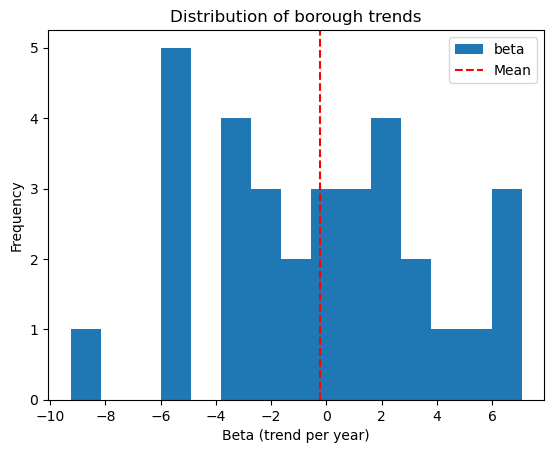

In [83]:
print(f"Mean beta across all boroughs: {results_df['beta'].mean():.3f}")
print(f"Std beta: {results_df['beta'].std():.3f}")

import matplotlib.pyplot as plt
results_df['beta'].plot.hist(bins=15)
plt.axvline(results_df['beta'].mean(), color='red', linestyle='--', label='Mean')
plt.xlabel('Beta (trend per year)')
plt.title('Distribution of borough trends')
plt.legend()
plt.show()

In [87]:
results_df['trend'] = results_df['beta'].apply(lambda x: 'increasing' if x > 0 else 'decreasing')
print(results_df.groupby('trend').size())
print(results_df.groupby('trend')['beta'].mean())

with pm.Model() as hierarchical_model:
    mu_alpha = pm.Normal('mu_alpha', mu=700, sigma=50)
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=50)
    mu_beta = pm.Normal('mu_beta', mu=-0.23, sigma=2)
    sigma_beta = pm.HalfNormal('sigma_beta', sigma=4)

    alpha_offset = pm.Normal('alpha_offset', mu=0, sigma=1, shape=n_boroughs)
    beta_offset = pm.Normal('beta_offset', mu=0, sigma=1, shape=n_boroughs)
    
    alpha = pm.Deterministic('alpha', mu_alpha + alpha_offset * sigma_alpha)
    beta = pm.Deterministic('beta', mu_beta + beta_offset * sigma_beta)

    gamma = pm.Normal('gamma', mu=-50, sigma=30)
    sigma = pm.HalfNormal('sigma', sigma=50)

    mu = alpha[borough_idx] + beta[borough_idx] * t_all + gamma * covid_all
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y_all)

    trace_h = pm.sample(2000, tune=1000, 
                        target_accept=0.95,
                        return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...


trend
decreasing    16
increasing    16
dtype: int64
trend
decreasing   -3.493654
increasing    3.031993
Name: beta, dtype: float64


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, mu_beta, sigma_beta, alpha_offset, beta_offset, gamma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


In [88]:
alpha_h = trace_h.posterior['alpha'].mean(dim=['chain', 'draw']).values
beta_h = trace_h.posterior['beta'].mean(dim=['chain', 'draw']).values

val_agg = val_df.groupby('LA_Name')['MEMS7_ALL'].mean()
test_agg = test_df.groupby('LA_Name')['MEMS7_ALL'].mean()

h_results = {}
for borough, idx in borough_map.items():
    val_pred = alpha_h[idx] + beta_h[idx] * 5
    test_pred = alpha_h[idx] + beta_h[idx] * 6
    h_results[borough] = {
        'val_mape': abs(val_pred - val_agg[borough]) / val_agg[borough] * 100,
        'test_mape': abs(test_pred - test_agg[borough]) / test_agg[borough] * 100
    }

h_results_df = pd.DataFrame(h_results).T
print("Hierarchical model:")
print(h_results_df[['val_mape', 'test_mape']].describe())
print("\nIndividual model:")
print(results_df[['val_mape', 'test_mape']].describe())

Hierarchical model:
        val_mape  test_mape
count  32.000000  32.000000
mean    9.828679   9.187477
std     6.294661   5.683843
min     0.285801   0.313883
25%     4.938247   5.280333
50%     9.739605   8.671721
75%    13.947133  13.231604
max    25.195392  18.988920

Individual model:
        val_mape  test_mape
count  32.000000  32.000000
mean    9.424661   8.286921
std     5.778824   5.108663
min     0.153592   0.500912
25%     4.603298   4.753789
50%     9.101375   7.358480
75%    14.201078  12.744436
max    23.927340  17.466138


DataFrame Cleaned Successfully...
DataFrame Information:
>>> Columns:
Index(['LA_2023', 'LondInOut', 'MEMS7_ALL', 'LOG_MEMS7_ALL', 'active', 'year',
       'LA_Name'],
      dtype='object')
>>> Shape (117679, 7)


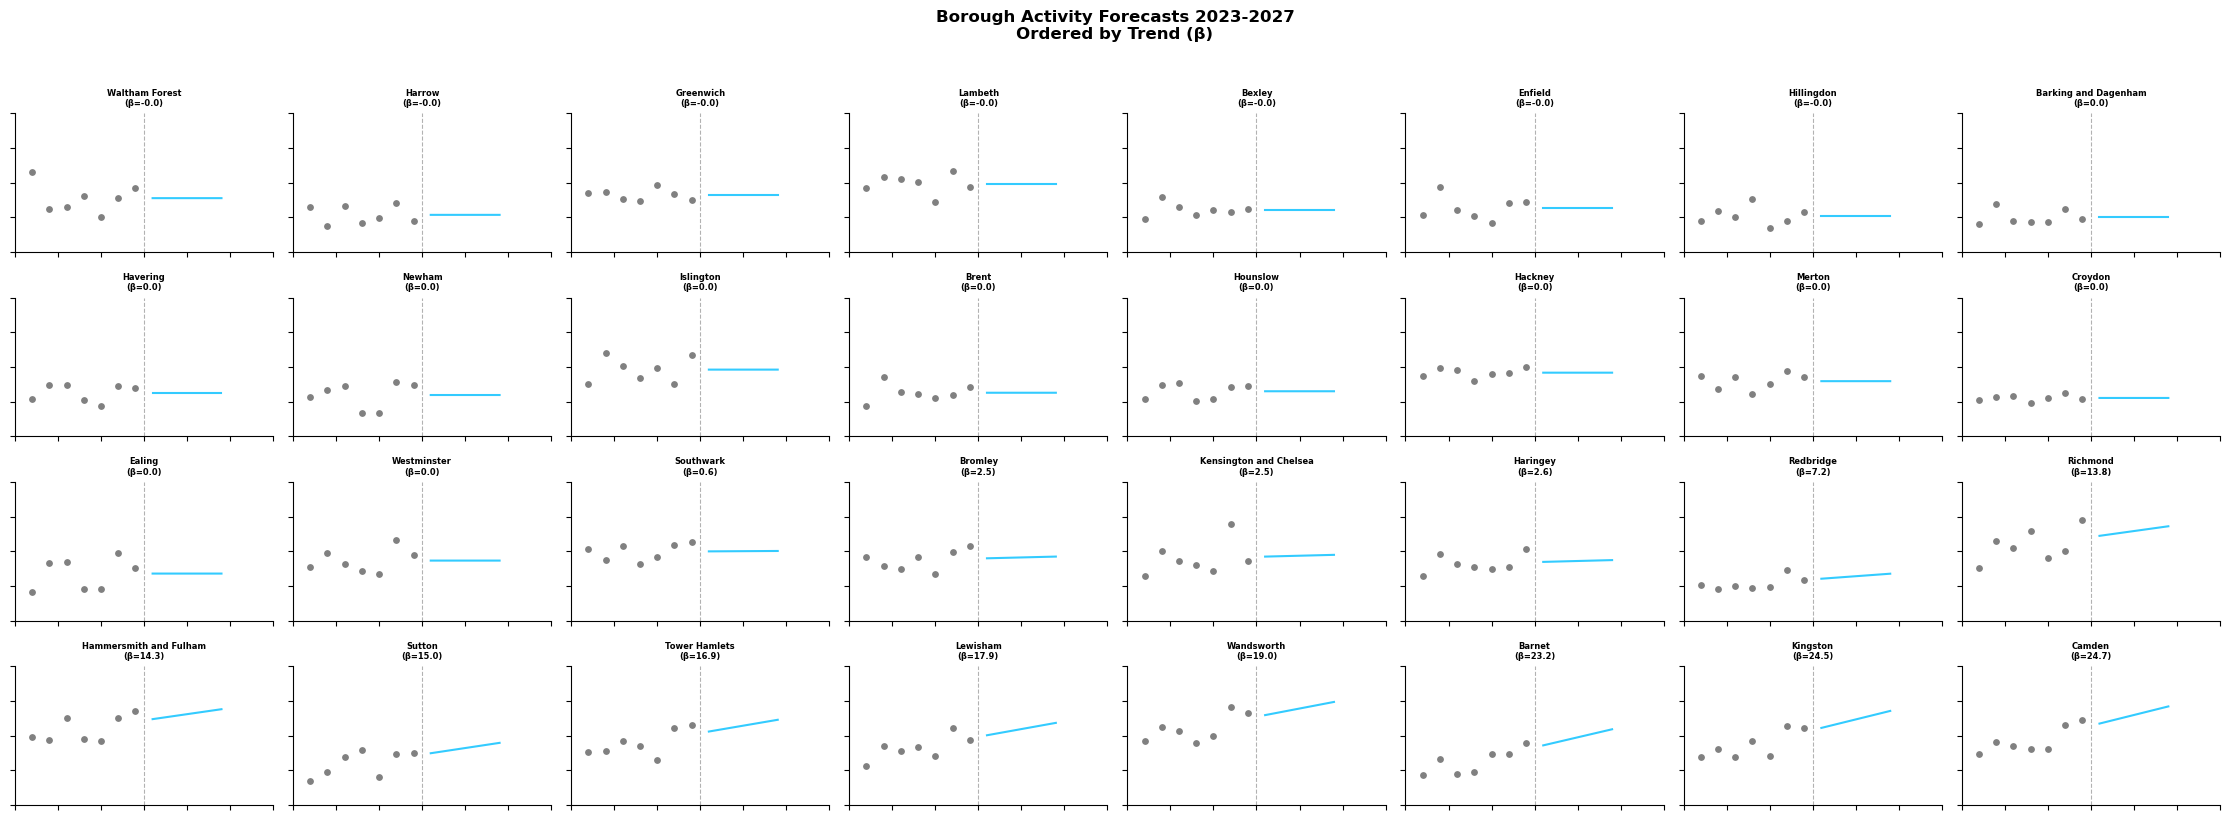

In [5]:
from prepare_boroughs import prepare_borough_data
from sklearn.linear_model import BayesianRidge
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

INCLUDED_YEARS = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
FORECAST_YEARS = [2023, 2024, 2025, 2026, 2027]

# Load and aggregate
borough_df = prepare_borough_data()
borough_df['year'] = borough_df['year'].str.split('/').str[0].astype(int)
borough_df = borough_df[borough_df['year'].isin(INCLUDED_YEARS)]
borough_agg = borough_df.groupby(['LA_Name', 'year'])['MEMS7_ALL'].mean().reset_index()

# Fit models
records = []
gradients = {}

for borough in borough_agg['LA_Name'].unique():
    b_data = borough_agg[borough_agg['LA_Name'] == borough].sort_values('year')
    Y_train = b_data['MEMS7_ALL'].values
    X_years = (np.array(INCLUDED_YEARS) - 2016).reshape(-1, 1)
    X_forecast = (np.array(FORECAST_YEARS) - 2016).reshape(-1, 1)

    model = BayesianRidge()
    model.fit(X_years, Y_train)
    gradients[borough] = model.coef_[0]

    Y_forecast, E_forecast = model.predict(X_forecast, return_std=True)

    for year, y in zip(INCLUDED_YEARS, Y_train):
        records.append({'borough': borough, 'year': year,
                        'participation': y, 'type': 'training'})
    for year, y, e in zip(FORECAST_YEARS, Y_forecast, E_forecast):
        records.append({'borough': borough, 'year': year,
                        'participation': y, 'type': 'forecast'})

full_df = pd.DataFrame(records)

# Order by gradient
borough_order = sorted(gradients, key=gradients.get)
full_df['borough'] = pd.Categorical(full_df['borough'],
                                     categories=borough_order, ordered=True)
full_df = full_df.sort_values('borough')

# Plot
g = sns.relplot(kind='line',
                data=full_df[full_df['type'] == 'forecast'],
                x='year',
                y='participation',
                col='borough',
                col_wrap=8,
                color='#00BFFF',
                height=2,
                aspect=1.4,
                alpha=0.8)

for borough, ax in g.axes_dict.items():
    t_df = full_df[(full_df['borough'] == borough) & (full_df['type'] == 'training')]
    ax.scatter(t_df['year'], t_df['participation'], color='grey', s=15, zorder=3)
    ax.axvline(x=2022.5, color='black', linestyle='--', alpha=0.3, linewidth=0.8)
    ax.set_title(f"{borough}\n(β={gradients[borough]:.1f})", fontsize=6, weight='bold')
    
g.set(xlabel='', ylabel='')
g.set_xticklabels([])
g.set_yticklabels([])
plt.suptitle('Borough Activity Forecasts 2023-2027\nOrdered by Trend (β)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/Borough_Forecast', bbox_inches='tight', dpi=150)
plt.show()